<a href="https://colab.research.google.com/github/meryymarta/DataMining/blob/main/Week11_perbandingan%20clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Age  Credit_amount  Duration  Employment_since      Purpose
0   25           2000        12                 2          car
1   40           7000        48                 5     business
2   35           3500        24                 4          car
3   23           1200        10                 1    furniture
4   52           9000        60                 5  real_estate


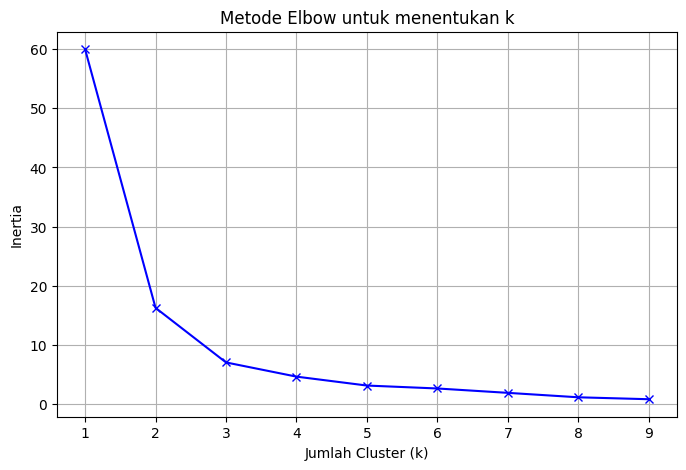

   Age  Credit_amount  Duration  Employment_since      Purpose  Cluster
0   25           2000        12                 2          car        2
1   40           7000        48                 5     business        0
2   35           3500        24                 4          car        1
3   23           1200        10                 1    furniture        2
4   52           9000        60                 5  real_estate        0


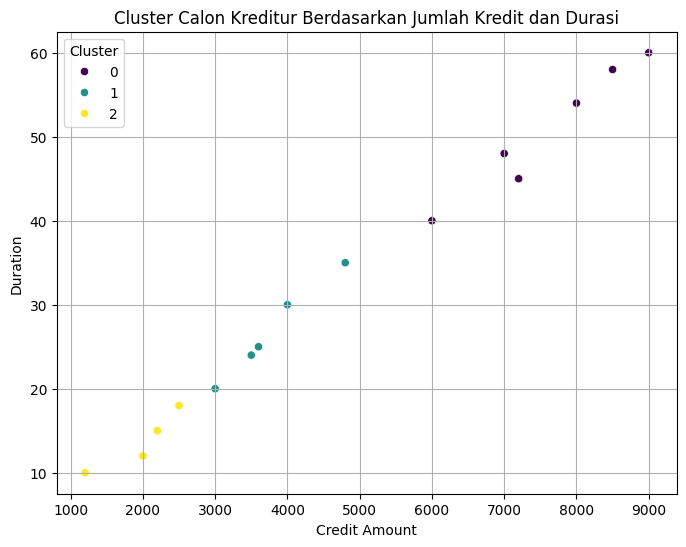


Silhouette Score: 0.549
Inertia (k=3): 7.016


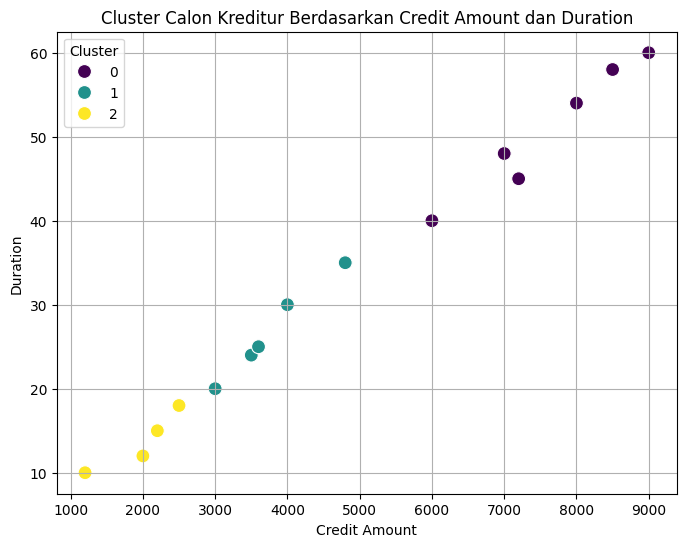

In [13]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from google.colab import drive
drive.mount('/content/drive')

# Load data
df = pd.read_csv ('/content/drive/MyDrive/kuliah/credit_data_sample.csv', sep=';')

# Tampilkan 5 data pertama
print(df.head())

# memilih fitur (numerik)
features = ['Age', 'Credit_amount', 'Duration', 'Employment_since']
X = df[features]

# Standarisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow Method
inertia = []
K = range(1, 10)

for k in K:
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit(X_scaled)
  inertia.append(kmeans.inertia_)

# Plot hasil elbow
plt.figure (figsize=(8,5))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Metode Elbow untuk menentukan k')
plt.grid(True)
plt.show()

# Melakukan K-Means clustering dengan 3 cluster
# Buat model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Menampilkan hasil clustering
print(df.head())

# Visualisasi hasil clustering
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Credit_amount'], y=df['Duration'],
hue=df['Cluster'], palette='viridis')
plt.title('Cluster Calon Kreditur Berdasarkan Jumlah Kredit dan Durasi')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.grid(True)
plt.show()

# Melihat performa dari K-Means model menggunakan silhouette score
# 7a. Hitung Silhouette Score
silhouette_avg = silhouette_score(X_scaled,
df['Cluster'])
print(f"\nSilhouette Score: {silhouette_avg:.3f}")

# 7b. Tampilkan inertia akhir
print(f"Inertia (k=3): {kmeans.inertia_:.3f}")

# Step 8 — Visualisasi hasil clustering (2 fitur: Credit_amount vs Duration)
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['Credit_amount'],
    y=df['Duration'],
    hue=df['Cluster'],
    palette='viridis',
    s=100
)
plt.title('Cluster Calon Kreditur Berdasarkan Credit Amount dan Duration')
plt.xlabel('Credit Amount')
plt.ylabel('Duration')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()


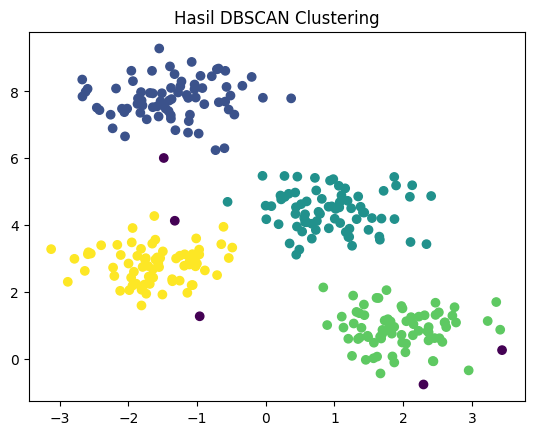

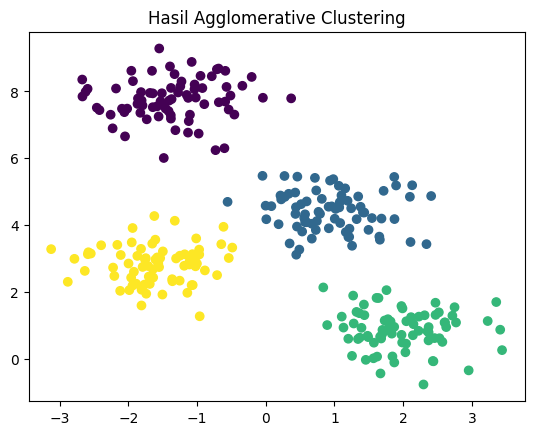

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs

# Membuat data contoh
X, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.60,
random_state=0)

# Menggunakan DBSCAN
dbscan = DBSCAN(eps=0.6, min_samples=4)
labels = dbscan.fit_predict(X)

# Visualisasi hasil clustering
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')
plt.title("Hasil DBSCAN Clustering")
plt.show()

# Menggunakan Agglomerative Clustering
agg_clust = AgglomerativeClustering(n_clusters=4)
agg_labels = agg_clust.fit_predict(X)

# Visualisasi hasil clustering
plt.scatter(X[:, 0], X[:, 1], c=agg_labels,
cmap='viridis')
plt.title("Hasil Agglomerative Clustering")
plt.show()

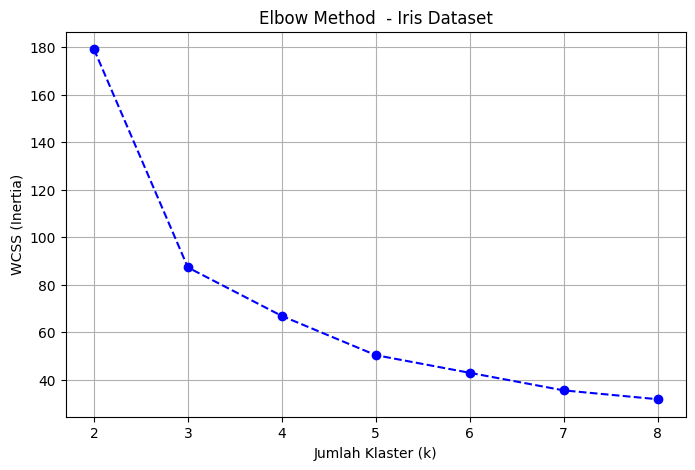

--- Nilai Silhouette Score (Label Sebagai Fitur) ---
k = 2 : 0.6801
k = 3 : 0.5819
k = 4 : 0.5387
k = 5 : 0.5136
k = 6 : 0.5208
k = 7 : 0.3866
k = 8 : 0.3515


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score

# 1. Load Dataset Iris
iris = load_iris()

# Membuat DataFrame gabungan antara Fitur Utama dan Label Target
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species_label'] = iris.target

# Menggunakan seluruh kolom (termasuk species_label) sebagai input K-Means
X = df.values

wcss = []
silhouette_scores = {}
k_range = range(2, 9)

# 2. Proses Perulangan K-Means untuk berbagai nilai k
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)

    # Simpan nilai WCSS (Inertia) untuk Elbow Method
    wcss.append(kmeans.inertia_)

    # Hitung nilai Silhouette Score
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores[k] = score

# 3. Membuat Grafik Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker='o', color='b', linestyle='--')
plt.title('Elbow Method  - Iris Dataset')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

# 4. Menampilkan Hasil Silhouette Score
print("--- Nilai Silhouette Score (Label Sebagai Fitur) ---")
for k, score in silhouette_scores.items():
    print(f"k = {k} : {score:.4f}")

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. PREPARASI DATA (Label Jadi Fitur)
# ==========================================
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species_label'] = iris.target

X = df.values

# Catatan: Untuk DBSCAN, standarisasi skala data sangat disarankan
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Tempat menyimpan hasil pengukuran
results = []

# ==========================================
# 2. RUN K-MEANS (k=3)
# ==========================================
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)
km_sil = silhouette_score(X, km_labels)
km_inertia = kmeans.inertia_

results.append({
    'Algoritma': 'K-Means (k=3)',
    'Silhouette Score': km_sil,
    'Inertia (WCSS)': f"{km_inertia:.4f}"
})

# ==========================================
# 3. RUN AGGLOMERATIVE CLUSTERING (n_clusters=3)
# ==========================================
agg = AgglomerativeClustering(n_clusters=3)
agg_labels = agg.fit_predict(X)
agg_sil = silhouette_score(X, agg_labels)

results.append({
    'Algoritma': 'Agglomerative (k=3)',
    'Silhouette Score': agg_sil,
    'Inertia (WCSS)': 'N/A (Tidak pakai centroid)'
})

# ==========================================
# 4. RUN DBSCAN (Gunakan X_scaled agar jarak terkontrol)
# ==========================================
# Melakukan tuning singkat agar DBSCAN bisa membentuk klaster yang logis
dbscan = DBSCAN(eps=0.8, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

# Hitung score jika klaster yang terbentuk valid (> 1 klaster dan bukan cuma noise)
if len(set(db_labels)) > 1:
    db_sil = silhouette_score(X_scaled, db_labels)
else:
    db_sil = float('nan')

results.append({
    'Algoritma': 'DBSCAN',
    'Silhouette Score': db_sil,
    'Inertia (WCSS)': 'N/A (Berdasarkan kerapatan)'
})

# ==========================================
# 5. TAMPILKAN TABEL PERBANDINGAN
# ==========================================
df_hasil = pd.DataFrame(results)
print(df_hasil.to_string(index=False))

          Algoritma  Silhouette Score              Inertia (WCSS)
      K-Means (k=3)          0.581897                     87.2206
Agglomerative (k=3)          0.578216  N/A (Tidak pakai centroid)
             DBSCAN          0.473823 N/A (Berdasarkan kerapatan)
